1. Real World Graph (Lecture 2A)
- For my real world graph, I am choosing the requirements management that we utilize for our software systems at my work. Being in the med-tech industry, when we submit hardware/software systems to the FDA in a 510k submission for clearance, we are required to show traceability for the entire system top to bottom. This flows from User Needs, to high level system requirements, to individual product requirements, software specs, and then code features. Tracking all of these dependencies is very tedious and is something that is continually being updated and worked on as we progress through often paralleled projects on the same products on different teams. Our company uses a 3rd party vendor to do this, but nonetheless, it's a perfect graph problem.
- The nodes would be the requirements, SW specs, or SW features. This could be implemented in the same graph or could be implemented in 3 separate graphs that point to each other.
- The edges represent the tracing from one requirements to another or from requirement to SW spec or from SW spec to SW feature. Since there are often multipled SW specs that trace up to a single requirement, and same with product level requirements to system level requirements, each vertice (node) is likely to have multiple edges and ancesstor vertices. 
- The edges are undirected  and unweighted because there is not a descriptive weight that characterizes the relationship between the nodes. The graph only needs to capture the strict parent-child relationships throughout the product requirements. Since questions about tracing can start at the SW spec level or the high system level, we need to be able to traverse the edges in either direction.

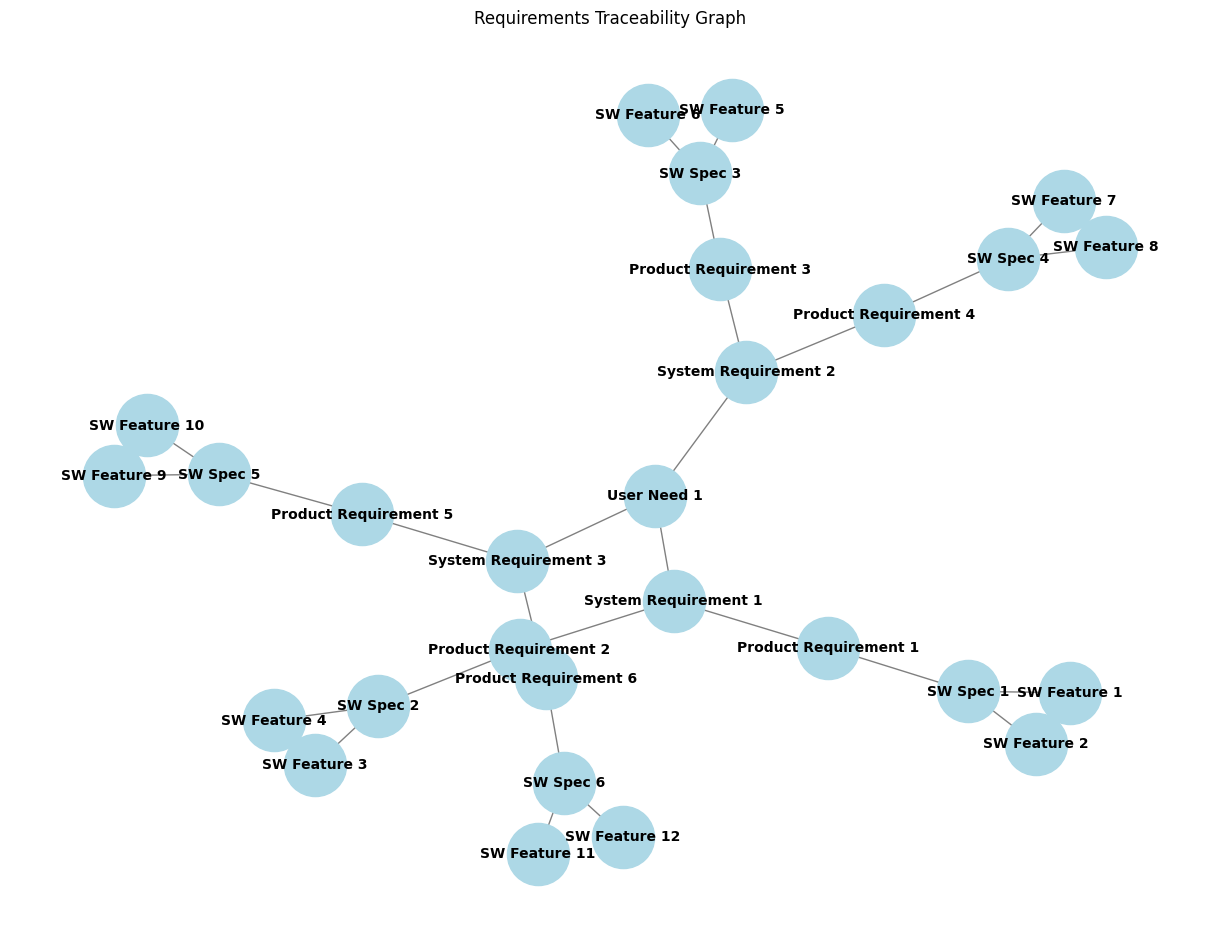

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Parameters for number of nodes at each level
num_system_reqs = 3
num_product_reqs_per_sys = 2
num_sw_specs_per_prod = 1
num_sw_features_per_spec = 2

ud_graph = nx.Graph()

# Add User Need
ud_graph.add_node("User Need 1")

# Add System Requirements
system_reqs = [f"System Requirement {i+1}" for i in range(num_system_reqs)]
ud_graph.add_nodes_from(system_reqs)
for sys_req in system_reqs:
    ud_graph.add_edge("User Need 1", sys_req)

# Add Product Requirements
product_reqs = []
for i, sys_req in enumerate(system_reqs):
    for j in range(num_product_reqs_per_sys):
        prod_req = f"Product Requirement {i*num_product_reqs_per_sys + j + 1}"
        product_reqs.append(prod_req)
        ud_graph.add_node(prod_req)
        ud_graph.add_edge(sys_req, prod_req)

# Add SW Specs
sw_specs = []
for i, prod_req in enumerate(product_reqs):
    for j in range(num_sw_specs_per_prod):
        sw_spec = f"SW Spec {i*num_sw_specs_per_prod + j + 1}"
        sw_specs.append(sw_spec)
        ud_graph.add_node(sw_spec)
        ud_graph.add_edge(prod_req, sw_spec)

# Add SW Features
sw_features = []
for i, sw_spec in enumerate(sw_specs):
    for j in range(num_sw_features_per_spec):
        sw_feat = f"SW Feature {i*num_sw_features_per_spec + j + 1}"
        sw_features.append(sw_feat)
        ud_graph.add_node(sw_feat)
        ud_graph.add_edge(sw_spec, sw_feat)

# Graph
plt.figure(figsize=(12,9))
pos = nx.spring_layout(ud_graph)
nx.draw(ud_graph, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, font_weight='bold', edge_color='gray')
plt.title("Requirements Traceability Graph")
plt.show()

2. Choosing the Right Graph Traversal for AI Problems
- Scenario A - Emergency Dispatch - An AI system must find the nearest available emergency vehicle in a city. All raods take approximately the same time to traverse.
    - The key here is that all roads take approximately the same time to traverse. This means that all the roads have the same weight, which in this case would be equivalent to them having no weights in the graph. BFS is best for graphs involving unweighted edges because the answer to the optimal solution here is given by minimzing the amount of edges (since they are all same weight) from the dispatch location to an emergency vehicle. 
- Scenario B - Dependency Analysis - An AI tool analyzes dependencies between software modules to detect cycles and understand build or execution order. The dependency graph is directed.
     - This problem is extremely akin to the dependency inequality problems described in the CLRS22 textbook titled Systems of difference constraints. A constraint graph, which is a weighted directed graph is utilized. It describes at each stage the minimum prior steps that must be completed before the current step can be completed. This is more akin to a Bell-Man Ford algorithm but a basic DFS algorithm can also be used since we need to discover any and all dependent components in the graph for the target vertice which represents the software module we are analyzing dependencies for.
- Scenario C - Maze exploration - an AI agent explores an unknown maze and must determine whether any path exists from the entrance to the exit. The agent does not need the shortest path.
    - The premise of what we need here is existence, not optimal. DFS is ideal for exploring all possibilities until a solution is found and naturally handles dead ends via backtracking due to its recursive implementation.
    - Also, since we don't need to find an optimal path, DFS is more memory efficient because it doesn't bother storing the full structure, just the current path being searched.
    

3. MSTs and Shortest Paths
- Scenario A - Data Center Server Wiring - A company is setting up a new data center with multiple server racks. Each possible cable connection between two racks has an associated installation cost. The goal is to ensure that all racks can communicate while keeping the total wiring cost as low as possible.
    - This represents a minimum spanning tree becaue you're trying to connect every rack into one working network, and the condition is all connected for the lowest total wiring cost, not best route between two specific racks.
- Scenario B - Package Delivery Route - A delivery driver must travel from a warehouse to a specific customer location. Roads between locations have different travel times, and traffic conditions affect the total cost of travel. The goal is to find the most efficient route between two locations.
    - This is a shortest path problem because it's from point to point. Start at the warehouse, end at one customer, and you want the most efficient route based on travel time/costs. Overall this will help them optimize their fleet.
- Scenario C - Smart Agriculture Sensor Network - A farm deploys soil and weather sensors across a large area. Each possible wireless link between sensors has an installation and maintenance cost. The goal is to ensure all sensors can transmit data while minimizing total network cost.
    - This is a minimum spanning tree because it's similar to the data center example. You want all sensors connected so data can flow across the network whle keeping overall costs down, not trying to figure out best/optimal connection for one.